## **Website Performance analysis project** ##

**Load the libraries and dataset**

In [51]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv(r'C:\Users\abrar\Downloads\data-export (1).csv')
df.head()


,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


### **Basic Data Cleaning** ###

**Fixed the real columns name of the dataset**

In [52]:
df.columns=df.iloc[0]
df.head()

,Session primary channel group (Default channel group),Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


**Remove the repeated row from the dataset**

In [53]:
df=df.drop(index=0).reset_index(drop=True)
df

,Session primary channel group (Default channel group),Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001
...,...,...,...,...,...,...,...,...,...,...
3177,Unassigned,2024042806,0,1,0,0,0,2,0,2
3178,Unassigned,2024043005,0,1,0,0,0,2,0,2
3179,Unassigned,2024043006,0,1,0,0,0,2,0,2
3180,Unassigned,2024050105,0,1,0,0,0,2,0,2


**Change the columns name of the dataset**

In [54]:
df=df.rename(columns={
    'Session primary channel group (Default channel group)':'Channel group',
    'Date + hour (YYYYMMDDHH)':'DateHour'
})
df.head()

,Channel group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


**Check the information of the dataset**

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   Channel group                        3182 non-null   object
 1   DateHour                             3182 non-null   object
 2   Users                                3182 non-null   object
 3   Sessions                             3182 non-null   object
 4   Engaged sessions                     3182 non-null   object
 5   Average engagement time per session  3182 non-null   object
 6   Engaged sessions per user            3182 non-null   object
 7   Events per session                   3182 non-null   object
 8   Engagement rate                      3182 non-null   object
 9   Event count                          3182 non-null   object
dtypes: object(10)
memory usage: 248.7+ KB


There have no null values in the dataset

**Change the dateHour column to date time formate**

In [56]:
df.columns

Index(['Channel group', 'DateHour', 'Users', 'Sessions', 'Engaged sessions',
       'Average engagement time per session', 'Engaged sessions per user',
       'Events per session', 'Engagement rate', 'Event count'],
      dtype='object', name=0)

In [57]:
df['DateHour']=pd.to_datetime(df['DateHour'],format='%Y%m%d%H',errors='coerce')
df.head()

,Channel group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024-04-16 23:00:00,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024-04-17 23:00:00,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


**Convert the data object type to numeric type**

In [58]:
numeric_cols=df.columns.drop(['Channel group','DateHour'])
df[numeric_cols]=df[numeric_cols].apply(pd.to_numeric,errors='coerce')
df.head()

,Channel group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Channel group                        3182 non-null   object        
 1   DateHour                             3182 non-null   datetime64[ns]
 2   Users                                3182 non-null   int64         
 3   Sessions                             3182 non-null   int64         
 4   Engaged sessions                     3182 non-null   int64         
 5   Average engagement time per session  3182 non-null   float64       
 6   Engaged sessions per user            3182 non-null   float64       
 7   Events per session                   3182 non-null   float64       
 8   Engagement rate                      3182 non-null   float64       
 9   Event count                          3182 non-null   int64         
dtypes: datetime6

**Creat a new columns of Hour extracted from DateHour column**

In [60]:
df['Hour']=df['DateHour'].dt.hour
df.head()

,Channel group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


**Description of the dataset**

In [61]:
df.describe()

,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-04-20 01:17:07.278441216,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:15:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


### **Exploratory Data Analysis** ###

**Sessions and users over time**

In [62]:
df.columns

Index(['Channel group', 'DateHour', 'Users', 'Sessions', 'Engaged sessions',
       'Average engagement time per session', 'Engaged sessions per user',
       'Events per session', 'Engagement rate', 'Event count', 'Hour'],
      dtype='object', name=0)

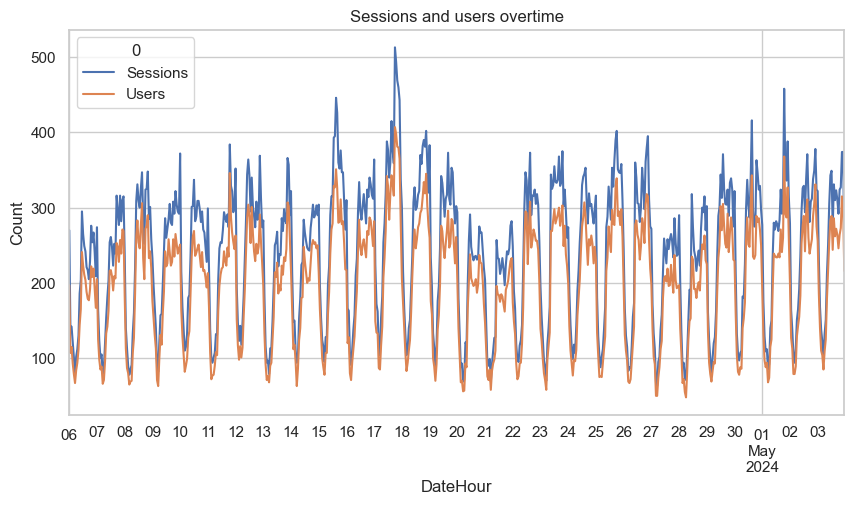

In [63]:

sns.set(style="whitegrid")
plt.figure(figsize=(10,5))
df.groupby('DateHour')[["Sessions",'Users']].sum().plot(ax=plt.gca())
plt.title('Sessions and users overtime')
plt.xlabel('DateHour')
plt.ylabel('Count')
plt.show()

The graph indicates consistent user activity with recurring traffic cycles. Sessions remain higher than users, showing repeated engagement. Peak traffic periods should be prioritized for business activities, while abnormal spikes should be further investigated for potential campaign impact.

**Total Users by channel**

In [64]:
df.columns

Index(['Channel group', 'DateHour', 'Users', 'Sessions', 'Engaged sessions',
       'Average engagement time per session', 'Engaged sessions per user',
       'Events per session', 'Engagement rate', 'Event count', 'Hour'],
      dtype='object', name=0)

C:\Users\abrar\AppData\Local\Temp\ipykernel_11880\3149503817.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x="Channel group",y="Users",estimator=np.sum,palette='viridis')


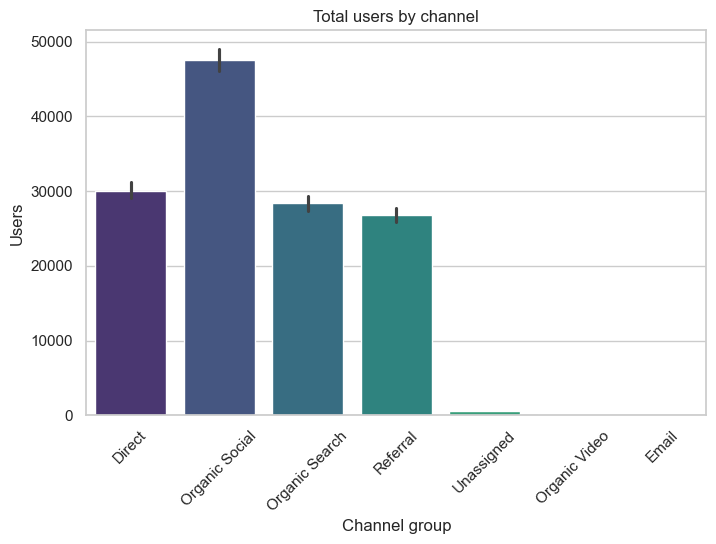

In [65]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="Channel group",y="Users",estimator=np.sum,palette='viridis')
plt.title("Total users by channel")
plt.xticks(rotation=45)
plt.show()

From the above graph we can see that organic social is the higest performing channel indicating that strong social media engagement. Also a huge amount of users come in the website through direct way and organic search indicating that good brand awarness and SEO performance.So, investment should be taken in this channels. However email and organic vedio show very low engagement and may require strategic improvement

**Average engagement time by channel**

C:\Users\abrar\AppData\Local\Temp\ipykernel_11880\3856504018.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x="Channel group",y='Average engagement time per session',estimator=np.mean,palette='magma')


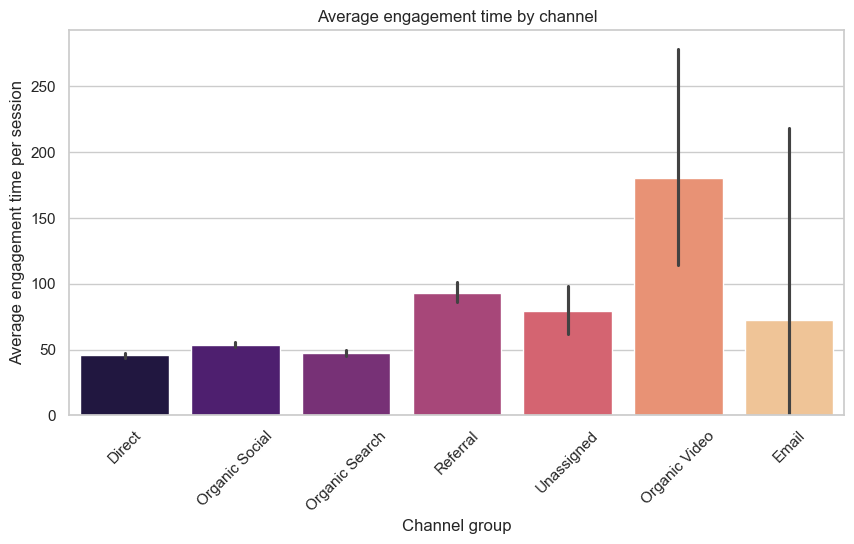

In [66]:
plt.figure(figsize=(10,5))
sns.barplot(data=df,x="Channel group",y='Average engagement time per session',estimator=np.mean,palette='magma')
plt.title('Average engagement time by channel')
plt.xticks(rotation=45)
plt.show()

From the graph we can see that organic vedio is organic vedio has the higest engagement time that means organic vedio provide high quality content that hold the traffic at a long time.So, necessary marketing strategy should be taken to bring more traffic through organic vedio.

**Engagement rate distribution by channel**

In [67]:
df.columns

Index(['Channel group', 'DateHour', 'Users', 'Sessions', 'Engaged sessions',
       'Average engagement time per session', 'Engaged sessions per user',
       'Events per session', 'Engagement rate', 'Event count', 'Hour'],
      dtype='object', name=0)

C:\Users\abrar\AppData\Local\Temp\ipykernel_11880\1663733819.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x="Channel group",y='Engagement rate',palette='coolwarm')


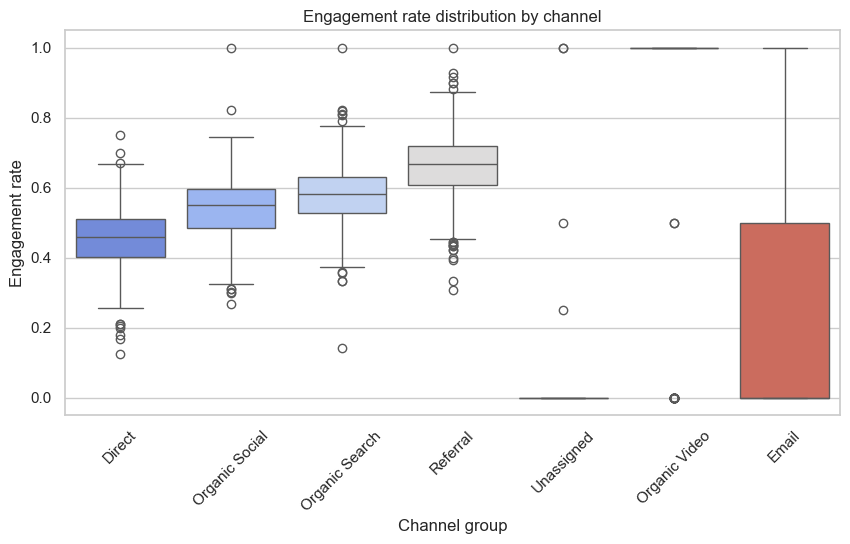

In [68]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df,x="Channel group",y='Engagement rate',palette='coolwarm')
plt.title('Engagement rate distribution by channel')
plt.xticks(rotation=45)
plt.show()

**Engagement Rate Distribution Analysis by Channel**

This box plot was used to analyze the distribution, variability, stability, consistency, and outliers of engagement rates across different traffic channels.

#### Key Insights

- Referral channel shows the highest median engagement rate, indicating that referral users are generally more engaged than users from other channels.
- Organic Search and Organic Social channels show relatively stable and consistent engagement behavior because their engagement values are concentrated within a narrower range.
- Direct traffic has comparatively lower engagement, suggesting that direct visitors may interact less with the platform.
- Email channel shows very high variability because its engagement values range from very low to very high. This indicates inconsistent user behavior and unstable campaign performance.
- Organic Video and Unassigned channels contain extreme values (0 and 1), which may indicate low sample size, tracking issues, or data quality problems.

#### Variability Analysis

- Variability refers to how much the engagement values fluctuate.
- A larger box and longer whiskers indicate higher variability.
- Email channel has the highest variability, meaning user engagement changes significantly across users.
- Organic Search has lower variability, indicating more predictable engagement behavior.

#### Stability Analysis

- Stable data means the engagement values do not fluctuate heavily.
- Organic Search appears more stable because its engagement values remain within a controlled range.
- Stable channels are important because they provide more reliable and predictable performance for business decisions.
- Email channel appears unstable due to its large spread and inconsistent engagement values.

#### User Consistency

- Consistent users behave similarly and produce engagement values within a similar range.
- Organic Social users appear relatively consistent because most engagement values are clustered around the middle range.
- Email users appear inconsistent because some users are highly engaged while others show almost no engagement.

#### Outlier Analysis

- The circles outside the whiskers represent outliers.
- Outliers indicate unusually high or unusually low engagement behavior.
- Referral channel contains several high-engagement outliers, meaning some users interacted far more than typical users.
- Outliers may also indicate unusual behavior patterns or possible tracking anomalies.

#### Overall Conclusion

- Referral traffic provides the highest-quality engagement.
- Organic Search and Organic Social channels provide more stable and reliable engagement performance.
- Email campaigns may require optimization because user engagement is highly inconsistent.
- Some channels may need further data validation due to extreme values and outliers.

**Engaged session vs Non engaged session**

In [69]:
df.columns

Index(['Channel group', 'DateHour', 'Users', 'Sessions', 'Engaged sessions',
       'Average engagement time per session', 'Engaged sessions per user',
       'Events per session', 'Engagement rate', 'Event count', 'Hour'],
      dtype='object', name=0)

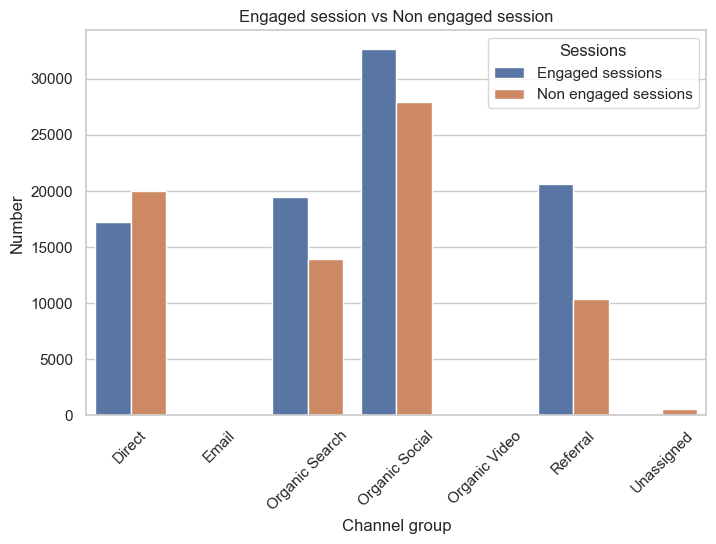

In [70]:
df_session= df.groupby('Channel group')[['Sessions','Engaged sessions']].sum().reset_index()
df_session['Non engaged sessions']=df_session['Sessions']-df_session['Engaged sessions']
df_session_melted=df_session.melt(id_vars='Channel group',value_vars=['Engaged sessions','Non engaged sessions'],var_name='Sessions',value_name='Number')
df_session_melted
plt.figure(figsize=(8,5))
sns.barplot(data=df_session_melted,x='Channel group',y='Number',hue='Sessions')
plt.title('Engaged session vs Non engaged session')
plt.xticks(rotation=45)
plt.show()


##### Insights from Engaged vs Non-Engaged Session Analysis

- Organic Social generated the highest traffic and engagement, showing strong social media performance.
- Organic Search also performed well, indicating effective SEO strategies.
- Referral traffic had significantly higher engaged sessions, suggesting high-quality external traffic sources.
- Direct traffic showed more non-engaged sessions, which may indicate poor landing page experience or weak user retention.
- Email traffic was extremely low, suggesting that email marketing is either inactive or ineffective.
- A small amount of unassigned traffic indicates possible issues in traffic source tracking or analytics configuration.

##### Business Decisions
- Continue investing in social media and SEO strategies.
- Improve user experience for direct visitors.
- Increase referral partnerships and backlink strategies.
- Develop stronger email marketing campaigns.
- Audit analytics tracking setup for proper traffic classification.

**Traffic by hour and channel**

In [71]:
heatmap_data=df.groupby(['Hour','Channel group'])['Sessions'].sum().unstack().fillna(0)
heatmap_data

Channel group,Direct,Email,Organic Search,Organic Social,Organic Video,Referral,Unassigned
Hour,,,,,,,
0,1684.0,0.0,1311.0,3917.0,6.0,1204.0,26.0
1,1196.0,0.0,984.0,2108.0,5.0,923.0,12.0
2,887.0,1.0,804.0,1537.0,2.0,755.0,13.0
3,771.0,0.0,606.0,1249.0,2.0,560.0,11.0
4,666.0,1.0,535.0,1081.0,2.0,495.0,6.0
5,679.0,0.0,506.0,951.0,1.0,453.0,8.0
6,768.0,0.0,639.0,1171.0,1.0,565.0,17.0
7,889.0,0.0,778.0,1524.0,2.0,743.0,10.0
8,1078.0,0.0,938.0,1886.0,4.0,862.0,13.0


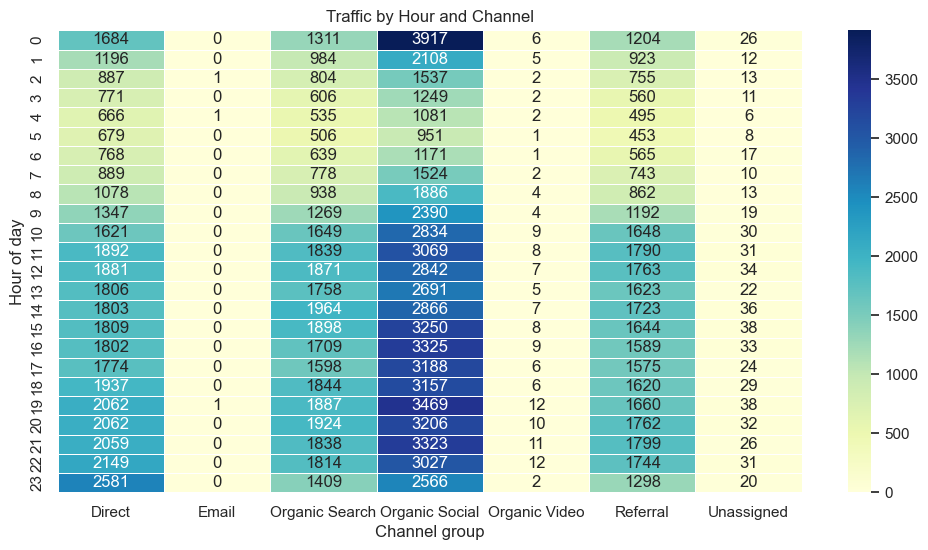

In [72]:
plt.figure(figsize=(12,6))
sns.heatmap(data=heatmap_data,cmap='YlGnBu',linewidths=.5,annot=True,fmt='.0f')
plt.title('Traffic by Hour and Channel')
plt.xlabel('Channel group')
plt.ylabel('Hour of day')
plt.show()

#### Traffic by Hour and Channel Analysis

The heatmap analysis reveals clear patterns in website traffic behavior across different hours and traffic channels.

##### Key Insights

- Organic Social was the strongest traffic source throughout the day and generated the highest overall traffic among all channels.
- The single highest traffic value was recorded at 12 AM (Hour 0) from Organic Social, indicating very strong late-night audience activity.
- Traffic generally increased after 9 AM and remained consistently high until late evening.
- The most consistently active period for overall website traffic was between 10 AM and 10 PM.
- Direct traffic became stronger during evening and late-night hours, suggesting the presence of returning or loyal visitors.
- Organic Search traffic remained stable throughout the day, showing consistent SEO performance.
- Referral traffic also contributed a significant amount of traffic during active hours, indicating valuable external traffic sources.
- Email and Organic Video channels generated very low traffic compared to other channels.
- A small amount of Unassigned traffic suggests possible analytics or traffic classification issues.

##### Business Decisions

- Focus marketing campaigns and important content publishing during afternoon and evening hours.
- Schedule social media posts and promotions during late-night hours, especially around 8 PM to 12 AM.
- Continue investing in social media marketing since Organic Social is the strongest traffic driver.
- Maintain and improve SEO strategies because Organic Search provides stable traffic throughout the day.
- Improve email marketing campaigns and video marketing strategies to increase engagement from weaker channels.
- Optimize website experience for late-night users, as audience activity is very high during nighttime.
- Audit analytics tracking and UTM configuration to reduce unassigned traffic sources.

**Engagement rate vs Sessions over time**

In [73]:
df.columns

Index(['Channel group', 'DateHour', 'Users', 'Sessions', 'Engaged sessions',
       'Average engagement time per session', 'Engaged sessions per user',
       'Events per session', 'Engagement rate', 'Event count', 'Hour'],
      dtype='object', name=0)

In [74]:
df_plot=df.groupby('DateHour')[['Engagement rate','Sessions']].mean().reset_index()
df_plot

,DateHour,Engagement rate,Sessions
0,2024-04-06 00:00:00,0.450262,54.000000
1,2024-04-06 01:00:00,0.489905,35.500000
2,2024-04-06 02:00:00,0.595759,35.500000
3,2024-04-06 03:00:00,0.446725,24.400000
4,2024-04-06 04:00:00,0.494964,25.500000
...,...,...,...
667,2024-05-03 19:00:00,0.498125,54.000000
668,2024-05-03 20:00:00,0.375790,54.500000
669,2024-05-03 21:00:00,0.471312,74.800000
670,2024-05-03 22:00:00,0.367749,62.333333


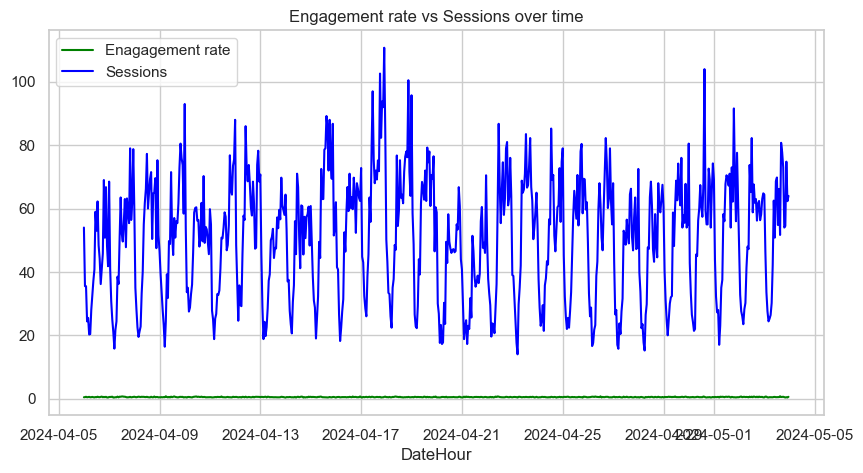

In [75]:
plt.figure(figsize=(10,5))
plt.plot(df_plot['DateHour'],df_plot['Engagement rate'],label='Enagagement rate',color='green')
plt.plot(df_plot['DateHour'],df_plot['Sessions'],label='Sessions',color='blue')
plt.title('Engagement rate vs Sessions over time')
plt.xlabel('DateHour')
plt.legend()
plt.grid(True)
plt.show()

#### Engagement Rate vs Sessions Over Time

This line graph compares the average **Sessions** and **Engagement Rate** over time based on the `DateHour` variable.

##### Key Insights:
- Website sessions fluctuate significantly over time, indicating varying user activity levels.
- Repeating peaks and drops suggest a periodic user behavior pattern, likely related to daily active and inactive hours.
- Several session spikes indicate periods of unusually high traffic, which may be caused by campaigns, promotions, or increased user interest.
- Overall traffic remains moderately consistent, with most session values staying within a common range.
- The engagement rate appears visually flat because it shares the same Y-axis with sessions, whose values are much larger.
- Due to the scale difference, the relationship between sessions and engagement rate cannot be analyzed clearly from this graph alone.
